In [10]:
import pandas as pd
import numpy as np
from PIL.ImageColor import colormap

In [11]:
df = pd.read_csv("placement.csv")

In [12]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0




# Steps

0. Preprocess + EDA + Feature Selection
1. Extract input and output cols
2. Scale the values
3. Train test split
4. Train the model
5. Evaluate the model/model selection
6. Deploy the model

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [14]:
df.drop(columns=["Unnamed: 0"],inplace=True)
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


<Axes: xlabel='cgpa', ylabel='iq'>

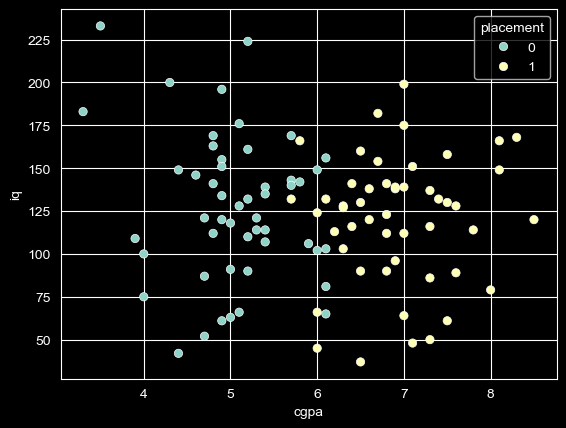

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(data=df, x="cgpa", y="iq", hue="placement")

In [28]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [25]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [29]:
y.shape

(100,)

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.1)

In [48]:
X_train

,cgpa,iq
61,7.3,137.0
37,8.1,149.0
64,7.0,64.0
12,5.4,139.0
89,4.9,151.0
...,...,...
48,6.6,138.0
67,5.0,118.0
86,5.1,128.0
58,8.0,79.0


In [49]:
y_train

61    1
37    1
64    1
12    0
89    0
     ..
48    1
67    0
86    0
58    1
81    0
Name: placement, Length: 90, dtype: int64

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [51]:
X_train = scaler.fit_transform(X_train)

In [52]:
X_train

array([[ 1.16665041,  0.31916237],
       [ 1.88153407,  0.62447269],
       [ 0.89856904, -1.5381421 ],
       [-0.53119827,  0.37004742],
       [-0.97800056,  0.67535774],
       [-0.2631169 ,  0.39548995],
       [-0.79927964, -1.48725705],
       [ 0.63048767,  0.75168532],
       [ 0.00496447, -0.01159048],
       [ 0.09432493,  0.19194973],
       [-0.70991919,  0.92978301],
       [-0.70991919, -0.8766364 ],
       [ 0.80920858,  0.37004742],
       [-0.70991919,  0.19194973],
       [-0.53119827,  0.26827731],
       [-0.97800056,  0.77712785],
       [ 0.09432493,  0.80257038],
       [ 0.89856904,  1.28597839],
       [ 0.9879295 ,  0.67535774],
       [ 1.25601087,  0.19194973],
       [-1.15672147, -0.08791807],
       [-0.8886401 , -1.56358463],
       [ 0.09432493, -1.10561914],
       [-0.08439599, -0.46955597],
       [-0.17375644,  0.446375  ],
       [-1.78224467, -1.2582743 ],
       [-1.42480284, -2.09787769],
       [ 1.34537133,  0.14106468],
       [ 2.2389759 ,

In [53]:
X_test = scaler.transform(X_test)

In [54]:
X_test

array([[-0.70991919, -0.36778586],
       [-1.06736102,  1.13332323],
       [ 0.71984813, -0.8766364 ],
       [-2.40776787,  1.4895186 ],
       [ 0.80920858, -0.72398124],
       [ 0.80920858,  0.34460489],
       [ 1.16665041, -1.89433748],
       [-0.97800056, -1.61446968],
       [ 1.34537133,  0.85345543],
       [ 0.00496447, -0.57132608]])

In [55]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [56]:
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [57]:
y_pred = clf.predict(X_test)

In [58]:
y_test

92    0
75    0
35    1
17    0
66    1
11    1
77    1
73    0
91    1
62    0
Name: placement, dtype: int64

In [62]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9

<Axes: >

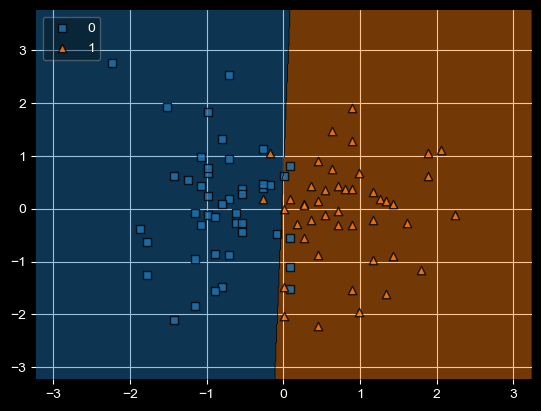

In [63]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train, y_train.values, clf = clf, legend=2)

In [64]:
import pickle
pickle.dump(clf,open('model.pkl','wb'))